https://www.kaggle.com/datasets/uciml/iris/data

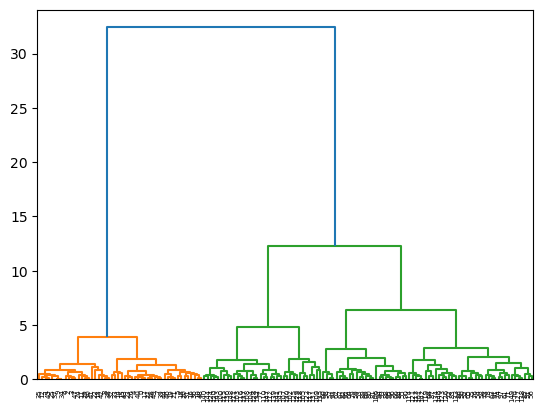

NORMALIZED:      SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0        -0.900681      1.032057      -1.341272     -1.312977
1        -1.143017     -0.124958      -1.341272     -1.312977
2        -1.385353      0.337848      -1.398138     -1.312977
3        -1.506521      0.106445      -1.284407     -1.312977
4        -1.021849      1.263460      -1.341272     -1.312977
..             ...           ...            ...           ...
145       1.038005     -0.124958       0.819624      1.447956
146       0.553333     -1.281972       0.705893      0.922064
147       0.795669     -0.124958       0.819624      1.053537
148       0.432165      0.800654       0.933356      1.447956
149       0.068662     -0.124958       0.762759      0.790591

[150 rows x 4 columns]


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import confusion_matrix, adjusted_rand_score
from scipy.optimize import linear_sum_assignment
from scipy.cluster.hierarchy import linkage,dendrogram
#import seaborn as sns


df = pd.read_csv('Iris.csv')


features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
X = df[features]

dendrogram(linkage(X,method="ward"))
plt.show()

scaler = MinMaxScaler()

X_normalized = X.copy()
X_normalized[features] = scaler.fit_transform(X[features])
X_normalized.head()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_normalized_sklearn = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print("NORMALIZED:",X_normalized_sklearn)





c:\Users\me01\miniconda3\envs\ML_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(




Adjusted Rand Index: 0.6201


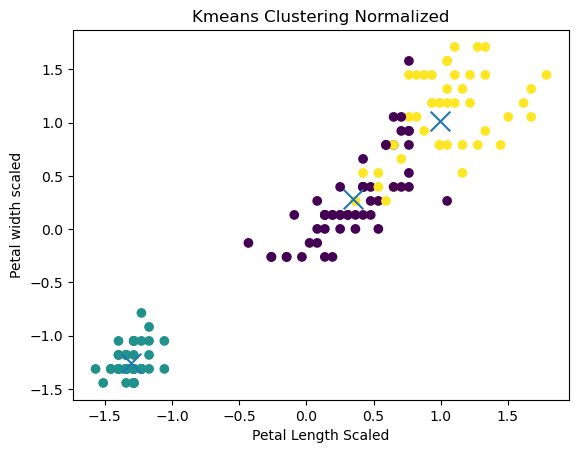

In [10]:
def km():
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    df['Cluster'] = clusters
    species_map = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
    df['Species_Numeric'] = df['Species'].map(species_map)
    ari_score = adjusted_rand_score(df['Species_Numeric'], df['Cluster'])
    print(f"\n\nAdjusted Rand Index: {ari_score:.4f}")
    plt.figure()
    plt.scatter(X_scaled[:,2],X_scaled[:,3],c=clusters)
    centers = kmeans.cluster_centers_
    plt.scatter(centers[:,2],centers[:,3],marker="x",s=200)
    plt.xlabel("Petal Length Scaled")
    plt.ylabel("Petal width scaled")
    plt.title("Kmeans Clustering Normalized")
    plt.show()
km()